In [1]:
print("Test")

Test


In [2]:
import pathlib
import random
import numpy as np

from scripts.DepChainTagger.config import SEED

random_seed = SEED
random.seed(SEED)
np.random.seed(SEED)

In [3]:
import pandas as pd
import ast
import tqdm
import glob
import sys
import estnltk
from estnltk.default_resolver import make_resolver
from estnltk.taggers import VabamorfAnalyzer
from estnltk_neural.taggers import StanzaSyntaxTagger

e:\Git_projects\EstNLTK\EstNLTK_DependencyChains\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import importlib
import scripts.DepChainTagger

# Reload the module to ensure that the latest changes are reflected
importlib.reload(scripts.DepChainTagger)
from scripts.DepChainTagger import (
    config,
    ConditionMode,
    DirectionMode,
    EdgeContext,
    SyntaxGraphIndex,
    ValueCondition,
    FeatureCondition,
    NodeConstraint,
    EdgeConstraint,
    PathPattern,
    ChainMatch,
    MatchCollector,
    PhraseDecorator,
    DepChainMatcher,
    DepTaggerOrchestrator,
    DepChainTagger,
    DepChildMatcher,
    DepChildTagger,
)

In [5]:
# Download the Stanza models for Estonian if not already present
stanza_syntax_tagger = StanzaSyntaxTagger(
    input_type="morph_analysis",
    input_morph_layer="morph_analysis",
    add_parent_and_children=True,
)
# estnltk.download("stanzasyntaxtagger")

In [6]:
# sample_text = "Ta andis lendurist abikaasale oma raamatu. See raamat on väga huvitav."
sample_text = "Üks ütles, et 1. mail tähistab palju maid töörahvapüha."
text_obj = estnltk.Text(sample_text)
text_obj.tag_layer("morph_extended")
# stanza_syntax_web_tagger.tag(text_obj)
stanza_syntax_tagger.tag(text_obj)

Text(text='Üks ütles, et 1. mail tähistab palju maid töörahvapüha.')

## Testing DepChainTagger


### Testing on sample sentence (1)


In [8]:
sample_text = "1990. aasta kuumal suvel vaatas Bureau Veritas Estline'i omanduseks saanud laeva uuesti üle."
text_obj = estnltk.Text(sample_text)
text_obj.tag_layer("morph_extended")
stanza_syntax_tagger.tag(text_obj)

display(text_obj.stanza_syntax)

sentence_layer = text_obj.sentences
stanza_syntax_layer = text_obj.stanza_syntax

# Check the DepChainTaggerOrchestrator implementation with the sample text
pattern = PathPattern(
    name="test",
    node_steps=(
        NodeConstraint(  # suvel
            role="s_1",
            attribute_conditions={"upostag": ValueCondition(ConditionMode.EXACT, "S")},
        ),
        NodeConstraint(  # aasta
            role="s_2",
            attribute_conditions={"upostag": ValueCondition(ConditionMode.EXACT, "S")},
        ),
        NodeConstraint(  # kuumal
            role="s_3",
            attribute_conditions={"upostag": ValueCondition(ConditionMode.EXACT, "S")},
        ),
    ),
    edge_steps=(
        EdgeConstraint(
            direction=DirectionMode.UP,
            # attribute_conditions={
            #     "deprel": ValueCondition(ConditionMode.EXACT, "nmod")
            # },
            min_hops=1,
            max_hops=1,
        ),
        EdgeConstraint(
            direction=DirectionMode.DOWN,
            attribute_conditions=None,
            min_hops=1,
            max_hops=2,
        ),
    ),
    emit_roles=("s_1", "s_2", "s_3"),
)

orchestrator = DepTaggerOrchestrator(
    patterns=(pattern,),
    global_dedup_mode="none",
    max_total_matches=1000000,
)

for i, sentence in enumerate(sentence_layer):
    sentence_span = (sentence.start, sentence.end)
    print(f"Sentence span: {sentence_span}, text: '{sentence.text}'")
    stanza_syntax_layer_sentence = sentence.stanza_syntax
    # Build syntax graph index from stanza_syntax layer
    graph_index = SyntaxGraphIndex(
        stanza_syntax_layer=stanza_syntax_layer_sentence,
        sentence_id=i,
        sentence_span=sentence_span,
    )

    # Run matcher
    matcher = orchestrator._get_matcher()
    matches = matcher.match_sentence(
        graph_index=graph_index,
        sentence_index=i,
        sentence_span=sentence_span,
    )

    print(f"Found {len(matches)} matches in sentence {i}.")
    for match in matches:
        print(match.describe())
        # for role, node in match.role_to_node.items():
        #     print(role, node.start, node.end, node.text, node.lemma, node.id)
    print("-" * 50)

Layer(name='stanza_syntax', attributes=('id', 'lemma', 'upostag', 'xpostag', 'feats', 'head', 'deprel', 'deps', 'misc', 'parent_span', 'children'), spans=SL[Span('1990.', [{'id': 1, 'lemma': '1990.', 'upostag': 'O', 'xpostag': 'O', 'feats': OrderedDict({'?': '?'}), 'head': 2, 'deprel': 'amod', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('aasta', [{'id': 2, 'lemma': 'aasta', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'g': 'g'}), 'head': 4, 'deprel': 'nmod', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': <class 'tuple'>}]),
Span('kuumal', [{'id': 3, 'lemma': 'kuum', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'ad': 'ad'}), 'head': 4, 'deprel': 'amod', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('suvel', [{'id': 4, 'lemma': 'suvi', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'ad': 'ad'}), 'head': 5, 'deprel': 'obl', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': <class 'tuple'>}]),
Span('vaatas', [{'id': 5, 'lemma': 'vaatama', 'upostag': 'V', 'xpostag': 'V', 'feats': OrderedDict({'s': 's'}), 'head': 0, 'deprel': 'root', 'deps': '_', 'misc': '_', 'parent_span': None, 'children': <class 'tuple'>}]),
Span('Bureau', [{'id': 6, 'lemma': 'Bureau', 'upostag': 'H', 'xpostag': 'H', 'feats': OrderedDict({'sg': 'sg', 'n': 'n'}), 'head': 5, 'deprel': 'nsubj', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': <class 'tuple'>}]),
Span('Veritas', [{'id': 7, 'lemma': 'Veritas', 'upostag': 'H', 'xpostag': 'H', 'feats': OrderedDict({'sg': 'sg', 'n': 'n'}), 'head': 6, 'deprel': 'flat', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span("Estline'i", [{'id': 8, 'lemma': 'Estline', 'upostag': 'H', 'xpostag': 'H', 'feats': OrderedDict({'sg': 'sg', 'g': 'g'}), 'head': 6, 'deprel': 'flat', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('omanduseks', [{'id': 9, 'lemma': 'omandus', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'tr': 'tr'}), 'head': 10, 'deprel': 'obj', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('saanud', [{'id': 10, 'lemma': 'saanud', 'upostag': 'A', 'xpostag': 'A', 'feats': OrderedDict({'sg': 'sg', 'n': 'n'}), 'head': 11, 'deprel': 'acl', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': <class 'tuple'>}]),
Span('laeva', [{'id': 11, 'lemma': 'laev', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'p': 'p'}), 'head': 5, 'deprel': 'obj', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': <class 'tuple'>}]),
Span('uuesti', [{'id': 12, 'lemma': 'uuesti', 'upostag': 'D', 'xpostag': 'D', 'feats': OrderedDict(), 'head': 5, 'deprel': 'advmod', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('üle', [{'id': 13, 'lemma': 'üle', 'upostag': 'D', 'xpostag': 'D', 'feats': OrderedDict(), 'head': 5, 'deprel': 'compound:prt', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('.', [{'id': 14, 'lemma': '.', 'upostag': 'Z', 'xpostag': 'Z', 'feats': OrderedDict(), 'head': 5, 'deprel': 'punct', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}])])

Sentence span: (0, 92), text: '['1990.', 'aasta', 'kuumal', 'suvel', 'vaatas', 'Bureau', 'Veritas', "Estline'i", 'omanduseks', 'saanud', 'laeva', 'uuesti', 'üle', '.']'
Found 2 matches in sentence 0.
Pattern name: test
Sentence index: 0
Sentence span: (0, 92)
Matched roles:
  Role: s_2, Token ID: 4, Node properties: {start: 19, end: 24, upostag: S, xpostag: S, lemma: suvi, feats: OrderedDict({'sg': 'sg', 'ad': 'ad'})}
  Role: s_1, Token ID: 2, Node properties: {start: 6, end: 11, upostag: S, xpostag: S, lemma: aasta, feats: OrderedDict({'sg': 'sg', 'g': 'g'})}
  Role: s_3, Token ID: 3, Node properties: {start: 12, end: 18, upostag: S, xpostag: S, lemma: kuum, feats: OrderedDict({'sg': 'sg', 'ad': 'ad'})}
Traversed edges:
  From role: s_1 to role: s_2, Edge context: {direction: up, deprel: nmod, hops: 1, crosses_sentence: False}
  From role: s_2 to role: s_3, Edge context: {direction: down, deprel: amod, hops: 1, crosses_sentence: False}
Matched text: 'aasta suvel kuumal'
Pattern name: 

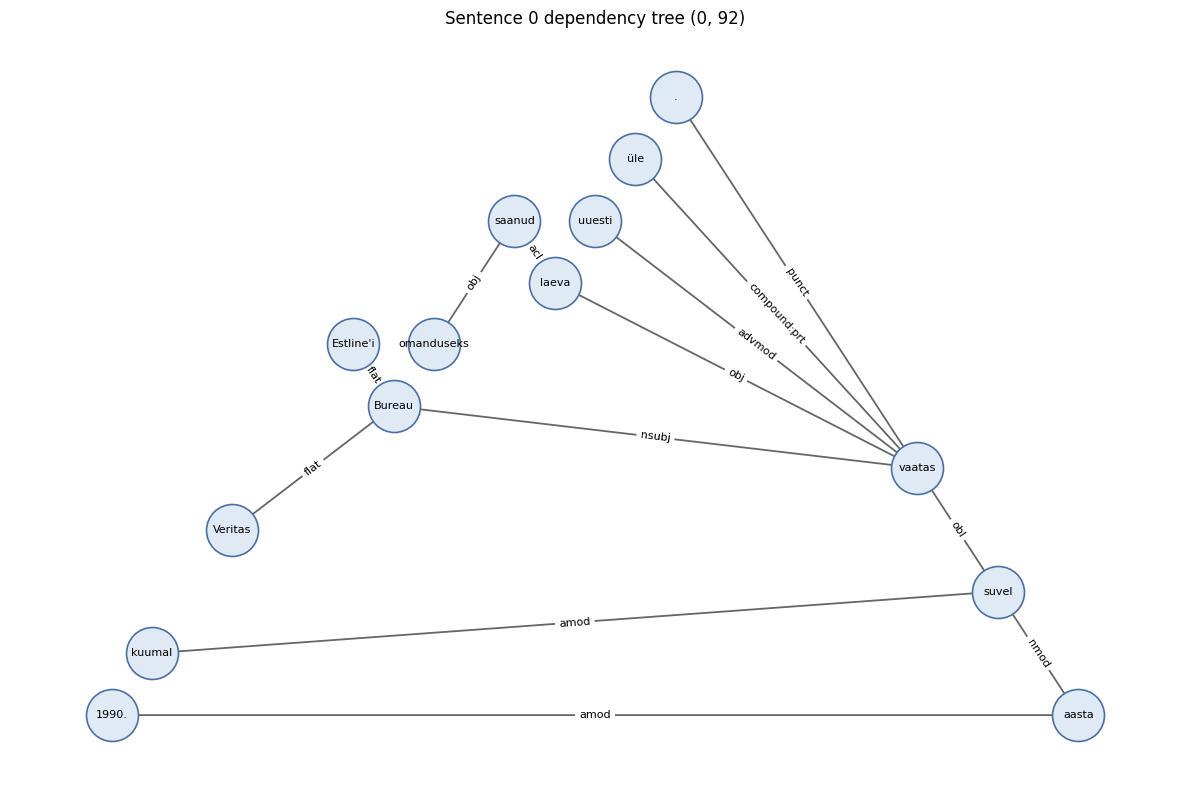

In [9]:
SyntaxGraphIndex.visualize(graph_index, layout="planar", node_size=1400, show=False)

In [10]:
# Testing DepChainTagger class and its EstNLTK-compatible wrapper on the sample text with the StanzaSyntaxTagger
tagger = DepChainTagger(
    patterns=(pattern,),
)

status = {}
tagger.tag(text_obj, status=status)
print(status.get("errors"))

None


In [11]:
print(text_obj["dep_chains"])

RelationLayer(name='dep_chains', span_names=('text',), attributes=('pattern_name', 'matched_text', 'upostag', 'xpostag', 'feats', 'lemma', 'deprel', 'role', 'is_anchor'), relations=[Relation([NamedSpan(text: 'aasta')], [{'pattern_name': 'test', 'matched_text': 'aasta suvel kuumal', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'g': 'g'}), 'lemma': 'aasta', 'deprel': 'nmod', 'role': 's_1', 'is_anchor': True}, {'pattern_name': 'test', 'matched_text': 'kuumal suvel aasta', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'g': 'g'}), 'lemma': 'aasta', 'deprel': 'nmod', 'role': 's_3', 'is_anchor': False}]), Relation([NamedSpan(text: 'suvel')], [{'pattern_name': 'test', 'matched_text': 'aasta suvel kuumal', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'ad': 'ad'}), 'lemma': 'suvi', 'deprel': 'obl', 'role': 's_2', 'is_anchor': False}, {'pattern_name': 'test', 'matched_text': 'kuumal suvel aasta', 'upostag': 'S', 'xpostag': 'S', 'feats'

In [12]:
display(text_obj["dep_chains"])

RelationLayer(name='dep_chains', span_names=('text',), attributes=('pattern_name', 'matched_text', 'upostag', 'xpostag', 'feats', 'lemma', 'deprel', 'role', 'is_anchor'), relations=[Relation([NamedSpan(text: 'aasta')], [{'pattern_name': 'test', 'matched_text': 'aasta suvel kuumal', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'g': 'g'}), 'lemma': 'aasta', 'deprel': 'nmod', 'role': 's_1', 'is_anchor': True}, {'pattern_name': 'test', 'matched_text': 'kuumal suvel aasta', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'g': 'g'}), 'lemma': 'aasta', 'deprel': 'nmod', 'role': 's_3', 'is_anchor': False}]), Relation([NamedSpan(text: 'suvel')], [{'pattern_name': 'test', 'matched_text': 'aasta suvel kuumal', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'ad': 'ad'}), 'lemma': 'suvi', 'deprel': 'obl', 'role': 's_2', 'is_anchor': False}, {'pattern_name': 'test', 'matched_text': 'kuumal suvel aasta', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'ad': 'ad'}), 'lemma': 'suvi', 'deprel': 'obl', 'role': 's_2', 'is_anchor': False}]), Relation([NamedSpan(text: 'kuumal')], [{'pattern_name': 'test', 'matched_text': 'aasta suvel kuumal', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'ad': 'ad'}), 'lemma': 'kuum', 'deprel': 'amod', 'role': 's_3', 'is_anchor': False}, {'pattern_name': 'test', 'matched_text': 'kuumal suvel aasta', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'ad': 'ad'}), 'lemma': 'kuum', 'deprel': 'amod', 'role': 's_1', 'is_anchor': True}])])

In [13]:
text_obj["dep_chains"].display()

1990. aasta text(0) kuumal text(2) suvel text(1) vaatas Bureau Veritas Estline'i omanduseks saanud laeva uuesti üle.

### Testing on sample sentence (2)


In [14]:
sample_text = "1990. aasta kuumal suvel vaatas Bureau Veritas Estline'i omanduseks saanud laeva uuesti üle."
text_obj = estnltk.Text(sample_text)
text_obj.tag_layer("morph_extended")
stanza_syntax_tagger.tag(text_obj)

display(text_obj.stanza_syntax)

sentence_layer = text_obj.sentences
stanza_syntax_layer = text_obj.stanza_syntax

# Check the DepChainTaggerOrchestrator implementation with the sample text
pattern = PathPattern(
    name="test",
    node_steps=(
        NodeConstraint(  # vaatas
            role="v",
            attribute_conditions={"upostag": ValueCondition(ConditionMode.EXACT, "V")},
        ),
        NodeConstraint(  # suvel
            role="s_1",
            attribute_conditions={"upostag": ValueCondition(ConditionMode.EXACT, "S")},
        ),
        NodeConstraint(  # aasta
            role="s_2",
            attribute_conditions={"upostag": ValueCondition(ConditionMode.EXACT, "S")},
        ),
        NodeConstraint(  # 1990.
            role="o",
            attribute_conditions={"upostag": ValueCondition(ConditionMode.EXACT, "O")},
        ),
    ),
    edge_steps=(
        EdgeConstraint(
            direction=DirectionMode.DOWN,
            # attribute_conditions={
            #     "deprel": ValueCondition(ConditionMode.EXACT, "nmod")
            # },
            min_hops=1,
            max_hops=1,
        ),
        EdgeConstraint(
            direction=DirectionMode.DOWN,
            attribute_conditions=None,
            min_hops=1,
            max_hops=1,
        ),
        EdgeConstraint(
            direction=DirectionMode.DOWN,
            attribute_conditions=None,
            min_hops=1,
            max_hops=1,
        ),
    ),
    emit_roles=("v", "s_1", "s_2", "o"),
)

orchestrator = DepTaggerOrchestrator(
    patterns=(pattern,),
    global_dedup_mode="none",
    max_total_matches=1000000,
)

for i, sentence in enumerate(sentence_layer):
    sentence_span = (sentence.start, sentence.end)
    print(f"Sentence span: {sentence_span}, text: '{sentence.text}'")
    stanza_syntax_layer_sentence = sentence.stanza_syntax
    # Build syntax graph index from stanza_syntax layer
    graph_index = SyntaxGraphIndex(
        stanza_syntax_layer=stanza_syntax_layer_sentence,
        sentence_id=i,
        sentence_span=sentence_span,
    )

    # Run matcher
    matcher = orchestrator._get_matcher()
    matches = matcher.match_sentence(
        graph_index=graph_index,
        sentence_index=i,
        sentence_span=sentence_span,
    )

    print(f"Found {len(matches)} matches in sentence {i}.")
    for match in matches:
        print(match.describe())
        # for role, node in match.role_to_node.items():
        #     print(role, node.start, node.end, node.text, node.lemma, node.id)
    print("-" * 50)

Layer(name='stanza_syntax', attributes=('id', 'lemma', 'upostag', 'xpostag', 'feats', 'head', 'deprel', 'deps', 'misc', 'parent_span', 'children'), spans=SL[Span('1990.', [{'id': 1, 'lemma': '1990.', 'upostag': 'O', 'xpostag': 'O', 'feats': OrderedDict({'?': '?'}), 'head': 2, 'deprel': 'amod', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('aasta', [{'id': 2, 'lemma': 'aasta', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'g': 'g'}), 'head': 4, 'deprel': 'nmod', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': <class 'tuple'>}]),
Span('kuumal', [{'id': 3, 'lemma': 'kuum', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'ad': 'ad'}), 'head': 4, 'deprel': 'amod', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('suvel', [{'id': 4, 'lemma': 'suvi', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'ad': 'ad'}), 'head': 5, 'deprel': 'obl', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': <class 'tuple'>}]),
Span('vaatas', [{'id': 5, 'lemma': 'vaatama', 'upostag': 'V', 'xpostag': 'V', 'feats': OrderedDict({'s': 's'}), 'head': 0, 'deprel': 'root', 'deps': '_', 'misc': '_', 'parent_span': None, 'children': <class 'tuple'>}]),
Span('Bureau', [{'id': 6, 'lemma': 'Bureau', 'upostag': 'H', 'xpostag': 'H', 'feats': OrderedDict({'sg': 'sg', 'n': 'n'}), 'head': 5, 'deprel': 'nsubj', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': <class 'tuple'>}]),
Span('Veritas', [{'id': 7, 'lemma': 'Veritas', 'upostag': 'H', 'xpostag': 'H', 'feats': OrderedDict({'sg': 'sg', 'n': 'n'}), 'head': 6, 'deprel': 'flat', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span("Estline'i", [{'id': 8, 'lemma': 'Estline', 'upostag': 'H', 'xpostag': 'H', 'feats': OrderedDict({'sg': 'sg', 'g': 'g'}), 'head': 6, 'deprel': 'flat', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('omanduseks', [{'id': 9, 'lemma': 'omandus', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'tr': 'tr'}), 'head': 10, 'deprel': 'obj', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('saanud', [{'id': 10, 'lemma': 'saanud', 'upostag': 'A', 'xpostag': 'A', 'feats': OrderedDict(), 'head': 11, 'deprel': 'acl', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': <class 'tuple'>}]),
Span('laeva', [{'id': 11, 'lemma': 'laev', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'p': 'p'}), 'head': 5, 'deprel': 'obj', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': <class 'tuple'>}]),
Span('uuesti', [{'id': 12, 'lemma': 'uuesti', 'upostag': 'D', 'xpostag': 'D', 'feats': OrderedDict(), 'head': 5, 'deprel': 'advmod', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('üle', [{'id': 13, 'lemma': 'üle', 'upostag': 'D', 'xpostag': 'D', 'feats': OrderedDict(), 'head': 5, 'deprel': 'compound:prt', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('.', [{'id': 14, 'lemma': '.', 'upostag': 'Z', 'xpostag': 'Z', 'feats': OrderedDict(), 'head': 5, 'deprel': 'punct', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}])])

Sentence span: (0, 92), text: '['1990.', 'aasta', 'kuumal', 'suvel', 'vaatas', 'Bureau', 'Veritas', "Estline'i", 'omanduseks', 'saanud', 'laeva', 'uuesti', 'üle', '.']'
Found 1 matches in sentence 0.
Pattern name: test
Sentence index: 0
Sentence span: (0, 92)
Matched roles:
  Role: s_2, Token ID: 2, Node properties: {start: 6, end: 11, upostag: S, xpostag: S, lemma: aasta, feats: OrderedDict({'sg': 'sg', 'g': 'g'})}
  Role: s_1, Token ID: 4, Node properties: {start: 19, end: 24, upostag: S, xpostag: S, lemma: suvi, feats: OrderedDict({'sg': 'sg', 'ad': 'ad'})}
  Role: o, Token ID: 1, Node properties: {start: 0, end: 5, upostag: O, xpostag: O, lemma: 1990., feats: OrderedDict({'?': '?'})}
  Role: v, Token ID: 5, Node properties: {start: 25, end: 31, upostag: V, xpostag: V, lemma: vaatama, feats: OrderedDict({'s': 's'})}
Traversed edges:
  From role: v to role: s_1, Edge context: {direction: down, deprel: obl, hops: 1, crosses_sentence: False}
  From role: s_1 to role: s_2, Edge context:

In [15]:
# Testing DepChainTagger class and its EstNLTK-compatible wrapper on the sample text with the StanzaSyntaxTagger
tagger = DepChainTagger(
    patterns=(pattern,),
)

status = {}
tagger.tag(text_obj, status=status)
print(status.get("errors"))

None


In [16]:
print(text_obj["dep_chains"])

RelationLayer(name='dep_chains', span_names=('text',), attributes=('pattern_name', 'matched_text', 'upostag', 'xpostag', 'feats', 'lemma', 'deprel', 'role', 'is_anchor'), relations=[Relation([NamedSpan(text: 'vaatas')], [{'pattern_name': 'test', 'matched_text': 'vaatas suvel aasta 1990.', 'upostag': 'V', 'xpostag': 'V', 'feats': OrderedDict({'s': 's'}), 'lemma': 'vaatama', 'deprel': 'root', 'role': 'v', 'is_anchor': True}]), Relation([NamedSpan(text: 'suvel')], [{'pattern_name': 'test', 'matched_text': 'vaatas suvel aasta 1990.', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'ad': 'ad'}), 'lemma': 'suvi', 'deprel': 'obl', 'role': 's_1', 'is_anchor': False}]), Relation([NamedSpan(text: 'aasta')], [{'pattern_name': 'test', 'matched_text': 'vaatas suvel aasta 1990.', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'g': 'g'}), 'lemma': 'aasta', 'deprel': 'nmod', 'role': 's_2', 'is_anchor': False}]), Relation([NamedSpan(text: '1990.')], [{'pattern_name'

In [17]:
display(text_obj["dep_chains"])

RelationLayer(name='dep_chains', span_names=('text',), attributes=('pattern_name', 'matched_text', 'upostag', 'xpostag', 'feats', 'lemma', 'deprel', 'role', 'is_anchor'), relations=[Relation([NamedSpan(text: 'vaatas')], [{'pattern_name': 'test', 'matched_text': 'vaatas suvel aasta 1990.', 'upostag': 'V', 'xpostag': 'V', 'feats': OrderedDict({'s': 's'}), 'lemma': 'vaatama', 'deprel': 'root', 'role': 'v', 'is_anchor': True}]), Relation([NamedSpan(text: 'suvel')], [{'pattern_name': 'test', 'matched_text': 'vaatas suvel aasta 1990.', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'ad': 'ad'}), 'lemma': 'suvi', 'deprel': 'obl', 'role': 's_1', 'is_anchor': False}]), Relation([NamedSpan(text: 'aasta')], [{'pattern_name': 'test', 'matched_text': 'vaatas suvel aasta 1990.', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'g': 'g'}), 'lemma': 'aasta', 'deprel': 'nmod', 'role': 's_2', 'is_anchor': False}]), Relation([NamedSpan(text: '1990.')], [{'pattern_name': 'test', 'matched_text': 'vaatas suvel aasta 1990.', 'upostag': 'O', 'xpostag': 'O', 'feats': OrderedDict({'?': '?'}), 'lemma': '1990.', 'deprel': 'amod', 'role': 'o', 'is_anchor': False}])])

In [18]:
text_obj["dep_chains"].display()

1990. text(3) aasta text(2) kuumal suvel text(1) vaatas text(0) Bureau Veritas Estline'i omanduseks saanud laeva uuesti üle.

### Testing on sample sentence (3)


In [19]:
sample_text = "1990. aasta kuumal suvel vaatas Bureau Veritas Estline'i omanduseks saanud laeva uuesti üle."
text_obj = estnltk.Text(sample_text)
text_obj.tag_layer("morph_extended")
stanza_syntax_tagger.tag(text_obj)

display(text_obj.stanza_syntax)

sentence_layer = text_obj.sentences
stanza_syntax_layer = text_obj.stanza_syntax

# Check the DepChainTaggerOrchestrator implementation with the sample text
pattern = PathPattern(
    name="test",
    node_steps=(
        NodeConstraint(  # vaatas
            role="o",
            attribute_conditions={"upostag": ValueCondition(ConditionMode.EXACT, "O")},
        ),
        NodeConstraint(  # suvel
            role="s_1",
            attribute_conditions={"upostag": ValueCondition(ConditionMode.EXACT, "S")},
        ),
        NodeConstraint(  # aasta
            role="s_2",
            attribute_conditions={"upostag": ValueCondition(ConditionMode.EXACT, "S")},
        ),
        NodeConstraint(  # 1990.
            role="v",
            attribute_conditions={"upostag": ValueCondition(ConditionMode.EXACT, "V")},
        ),
    ),
    edge_steps=(
        EdgeConstraint(
            direction=DirectionMode.UP,
            # attribute_conditions={
            #     "deprel": ValueCondition(ConditionMode.EXACT, "nmod")
            # },
            min_hops=1,
            max_hops=1,
        ),
        EdgeConstraint(
            direction=DirectionMode.UP,
            attribute_conditions=None,
            min_hops=1,
            max_hops=1,
        ),
        EdgeConstraint(
            direction=DirectionMode.UP,
            attribute_conditions=None,
            min_hops=1,
            max_hops=1,
        ),
    ),
    emit_roles=("o", "s_1", "s_2", "v"),
)

orchestrator = DepTaggerOrchestrator(
    patterns=(pattern,),
    global_dedup_mode="none",
    max_total_matches=1000000,
)

for i, sentence in enumerate(sentence_layer):
    sentence_span = (sentence.start, sentence.end)
    print(f"Sentence span: {sentence_span}, text: '{sentence.text}'")
    stanza_syntax_layer_sentence = sentence.stanza_syntax
    # Build syntax graph index from stanza_syntax layer
    graph_index = SyntaxGraphIndex(
        stanza_syntax_layer=stanza_syntax_layer_sentence,
        sentence_id=i,
        sentence_span=sentence_span,
    )

    # Run matcher
    matcher = orchestrator._get_matcher()
    matches = matcher.match_sentence(
        graph_index=graph_index,
        sentence_index=i,
        sentence_span=sentence_span,
    )

    print(f"Found {len(matches)} matches in sentence {i}.")
    for match in matches:
        print(match.describe())
        # for role, node in match.role_to_node.items():
        #     print(role, node.start, node.end, node.text, node.lemma, node.id)
    print("-" * 50)

Layer(name='stanza_syntax', attributes=('id', 'lemma', 'upostag', 'xpostag', 'feats', 'head', 'deprel', 'deps', 'misc', 'parent_span', 'children'), spans=SL[Span('1990.', [{'id': 1, 'lemma': '1990.', 'upostag': 'O', 'xpostag': 'O', 'feats': OrderedDict({'?': '?'}), 'head': 2, 'deprel': 'amod', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('aasta', [{'id': 2, 'lemma': 'aasta', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'g': 'g'}), 'head': 4, 'deprel': 'nmod', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': <class 'tuple'>}]),
Span('kuumal', [{'id': 3, 'lemma': 'kuum', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'ad': 'ad'}), 'head': 4, 'deprel': 'amod', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('suvel', [{'id': 4, 'lemma': 'suvi', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'ad': 'ad'}), 'head': 5, 'deprel': 'obl', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': <class 'tuple'>}]),
Span('vaatas', [{'id': 5, 'lemma': 'vaatama', 'upostag': 'V', 'xpostag': 'V', 'feats': OrderedDict({'s': 's'}), 'head': 0, 'deprel': 'root', 'deps': '_', 'misc': '_', 'parent_span': None, 'children': <class 'tuple'>}]),
Span('Bureau', [{'id': 6, 'lemma': 'Bureau', 'upostag': 'H', 'xpostag': 'H', 'feats': OrderedDict({'sg': 'sg', 'n': 'n'}), 'head': 5, 'deprel': 'nsubj', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': <class 'tuple'>}]),
Span('Veritas', [{'id': 7, 'lemma': 'Veritas', 'upostag': 'H', 'xpostag': 'H', 'feats': OrderedDict({'sg': 'sg', 'n': 'n'}), 'head': 6, 'deprel': 'flat', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span("Estline'i", [{'id': 8, 'lemma': 'Estline', 'upostag': 'H', 'xpostag': 'H', 'feats': OrderedDict({'sg': 'sg', 'g': 'g'}), 'head': 6, 'deprel': 'flat', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('omanduseks', [{'id': 9, 'lemma': 'omandus', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'tr': 'tr'}), 'head': 10, 'deprel': 'obj', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('saanud', [{'id': 10, 'lemma': 'saanud', 'upostag': 'A', 'xpostag': 'A', 'feats': OrderedDict({'sg': 'sg', 'n': 'n'}), 'head': 11, 'deprel': 'acl', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': <class 'tuple'>}]),
Span('laeva', [{'id': 11, 'lemma': 'laev', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'p': 'p'}), 'head': 5, 'deprel': 'obj', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': <class 'tuple'>}]),
Span('uuesti', [{'id': 12, 'lemma': 'uuesti', 'upostag': 'D', 'xpostag': 'D', 'feats': OrderedDict(), 'head': 5, 'deprel': 'advmod', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('üle', [{'id': 13, 'lemma': 'üle', 'upostag': 'D', 'xpostag': 'D', 'feats': OrderedDict(), 'head': 5, 'deprel': 'compound:prt', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('.', [{'id': 14, 'lemma': '.', 'upostag': 'Z', 'xpostag': 'Z', 'feats': OrderedDict(), 'head': 5, 'deprel': 'punct', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}])])

Sentence span: (0, 92), text: '['1990.', 'aasta', 'kuumal', 'suvel', 'vaatas', 'Bureau', 'Veritas', "Estline'i", 'omanduseks', 'saanud', 'laeva', 'uuesti', 'üle', '.']'
Found 1 matches in sentence 0.
Pattern name: test
Sentence index: 0
Sentence span: (0, 92)
Matched roles:
  Role: s_1, Token ID: 2, Node properties: {start: 6, end: 11, upostag: S, xpostag: S, lemma: aasta, feats: OrderedDict({'sg': 'sg', 'g': 'g'})}
  Role: o, Token ID: 1, Node properties: {start: 0, end: 5, upostag: O, xpostag: O, lemma: 1990., feats: OrderedDict({'?': '?'})}
  Role: s_2, Token ID: 4, Node properties: {start: 19, end: 24, upostag: S, xpostag: S, lemma: suvi, feats: OrderedDict({'sg': 'sg', 'ad': 'ad'})}
  Role: v, Token ID: 5, Node properties: {start: 25, end: 31, upostag: V, xpostag: V, lemma: vaatama, feats: OrderedDict({'s': 's'})}
Traversed edges:
  From role: o to role: s_1, Edge context: {direction: up, deprel: amod, hops: 1, crosses_sentence: False}
  From role: s_1 to role: s_2, Edge context: 

In [20]:
# Testing DepChainTagger class and its EstNLTK-compatible wrapper on the sample text with the StanzaSyntaxTagger
tagger = DepChainTagger(
    patterns=(pattern,),
)

status = {}
tagger.tag(text_obj, status=status)
print(status.get("errors"))

None


In [21]:
print(text_obj["dep_chains"])

RelationLayer(name='dep_chains', span_names=('text',), attributes=('pattern_name', 'matched_text', 'upostag', 'xpostag', 'feats', 'lemma', 'deprel', 'role', 'is_anchor'), relations=[Relation([NamedSpan(text: '1990.')], [{'pattern_name': 'test', 'matched_text': '1990. aasta suvel vaatas', 'upostag': 'O', 'xpostag': 'O', 'feats': OrderedDict({'?': '?'}), 'lemma': '1990.', 'deprel': 'amod', 'role': 'o', 'is_anchor': True}]), Relation([NamedSpan(text: 'aasta')], [{'pattern_name': 'test', 'matched_text': '1990. aasta suvel vaatas', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'g': 'g'}), 'lemma': 'aasta', 'deprel': 'nmod', 'role': 's_1', 'is_anchor': False}]), Relation([NamedSpan(text: 'suvel')], [{'pattern_name': 'test', 'matched_text': '1990. aasta suvel vaatas', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'ad': 'ad'}), 'lemma': 'suvi', 'deprel': 'obl', 'role': 's_2', 'is_anchor': False}]), Relation([NamedSpan(text: 'vaatas')], [{'pattern_name': 

In [22]:
display(text_obj["dep_chains"])

RelationLayer(name='dep_chains', span_names=('text',), attributes=('pattern_name', 'matched_text', 'upostag', 'xpostag', 'feats', 'lemma', 'deprel', 'role', 'is_anchor'), relations=[Relation([NamedSpan(text: '1990.')], [{'pattern_name': 'test', 'matched_text': '1990. aasta suvel vaatas', 'upostag': 'O', 'xpostag': 'O', 'feats': OrderedDict({'?': '?'}), 'lemma': '1990.', 'deprel': 'amod', 'role': 'o', 'is_anchor': True}]), Relation([NamedSpan(text: 'aasta')], [{'pattern_name': 'test', 'matched_text': '1990. aasta suvel vaatas', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'g': 'g'}), 'lemma': 'aasta', 'deprel': 'nmod', 'role': 's_1', 'is_anchor': False}]), Relation([NamedSpan(text: 'suvel')], [{'pattern_name': 'test', 'matched_text': '1990. aasta suvel vaatas', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'ad': 'ad'}), 'lemma': 'suvi', 'deprel': 'obl', 'role': 's_2', 'is_anchor': False}]), Relation([NamedSpan(text: 'vaatas')], [{'pattern_name': 'test', 'matched_text': '1990. aasta suvel vaatas', 'upostag': 'V', 'xpostag': 'V', 'feats': OrderedDict({'s': 's'}), 'lemma': 'vaatama', 'deprel': 'root', 'role': 'v', 'is_anchor': False}])])

In [23]:
text_obj["dep_chains"].display()

1990. text(0) aasta text(1) kuumal suvel text(2) vaatas text(3) Bureau Veritas Estline'i omanduseks saanud laeva uuesti üle.

## Testing DepChildTagger


### Testing on sample sentence (1)


In [ ]:
sample_text = "1990. aasta kuumal suvel vaatas Bureau Veritas Estline'i omanduseks saanud laeva uuesti üle."
text_obj = estnltk.Text(sample_text)
text_obj.tag_layer("morph_extended")
stanza_syntax_tagger.tag(text_obj)

display(text_obj.stanza_syntax)

sentence_layer = text_obj.sentences
stanza_syntax_layer = text_obj.stanza_syntax

# Check the DepChainTaggerOrchestrator implementation with the sample text
pattern = PathPattern(
    name="test",
    node_steps=(
        NodeConstraint(  # vaatas
            role="v",
            attribute_conditions={"upostag": ValueCondition(ConditionMode.EXACT, "V")},
        ),
        NodeConstraint(
            role="s_1",
            attribute_conditions={"upostag": ValueCondition(ConditionMode.EXACT, "S")},
        ),
    ),
    edge_steps=(
        EdgeConstraint(
            direction=DirectionMode.DOWN,
            # attribute_conditions={
            #     "deprel": ValueCondition(ConditionMode.EXACT, "nmod")
            # },
            min_hops=1,
            max_hops=4,
        ),
    ),
    emit_roles=("v", "s_1"),
)

orchestrator = DepTaggerOrchestrator(
    patterns=(pattern,),
    global_dedup_mode="none",
    max_total_matches=1000000,
)

for i, sentence in enumerate(sentence_layer):
    sentence_span = (sentence.start, sentence.end)
    print(f"Sentence span: {sentence_span}, text: '{sentence.text}'")
    stanza_syntax_layer_sentence = sentence.stanza_syntax
    # Build syntax graph index from stanza_syntax layer
    graph_index = SyntaxGraphIndex(
        stanza_syntax_layer=stanza_syntax_layer_sentence,
        sentence_id=i,
        sentence_span=sentence_span,
    )

    # Run matcher
    matcher = orchestrator._get_matcher()
    matches = matcher.match_sentence(
        graph_index=graph_index,
        sentence_index=i,
        sentence_span=sentence_span,
    )

    print(f"Found {len(matches)} matches in sentence {i}.")
    for match in matches:
        print(match.describe())
        # for role, node in match.role_to_node.items():
        #     print(role, node.start, node.end, node.text, node.lemma, node.id)
    print("-" * 50)

Layer(name='stanza_syntax', attributes=('id', 'lemma', 'upostag', 'xpostag', 'feats', 'head', 'deprel', 'deps', 'misc', 'parent_span', 'children'), spans=SL[Span('1990.', [{'id': 1, 'lemma': '1990.', 'upostag': 'O', 'xpostag': 'O', 'feats': OrderedDict({'?': '?'}), 'head': 2, 'deprel': 'amod', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('aasta', [{'id': 2, 'lemma': 'aasta', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'g': 'g'}), 'head': 4, 'deprel': 'nmod', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': <class 'tuple'>}]),
Span('kuumal', [{'id': 3, 'lemma': 'kuum', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'ad': 'ad'}), 'head': 4, 'deprel': 'amod', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('suvel', [{'id': 4, 'lemma': 'suvi', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'ad': 'ad'}), 'head': 5, 'deprel': 'obl', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': <class 'tuple'>}]),
Span('vaatas', [{'id': 5, 'lemma': 'vaatama', 'upostag': 'V', 'xpostag': 'V', 'feats': OrderedDict({'s': 's'}), 'head': 0, 'deprel': 'root', 'deps': '_', 'misc': '_', 'parent_span': None, 'children': <class 'tuple'>}]),
Span('Bureau', [{'id': 6, 'lemma': 'Bureau', 'upostag': 'H', 'xpostag': 'H', 'feats': OrderedDict({'sg': 'sg', 'n': 'n'}), 'head': 5, 'deprel': 'nsubj', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': <class 'tuple'>}]),
Span('Veritas', [{'id': 7, 'lemma': 'Veritas', 'upostag': 'H', 'xpostag': 'H', 'feats': OrderedDict({'sg': 'sg', 'n': 'n'}), 'head': 6, 'deprel': 'flat', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span("Estline'i", [{'id': 8, 'lemma': 'Estline', 'upostag': 'H', 'xpostag': 'H', 'feats': OrderedDict({'sg': 'sg', 'g': 'g'}), 'head': 6, 'deprel': 'flat', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('omanduseks', [{'id': 9, 'lemma': 'omandus', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'tr': 'tr'}), 'head': 10, 'deprel': 'obj', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('saanud', [{'id': 10, 'lemma': 'saama', 'upostag': 'V', 'xpostag': 'V', 'feats': OrderedDict({'nud': 'nud'}), 'head': 11, 'deprel': 'acl', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': <class 'tuple'>}]),
Span('laeva', [{'id': 11, 'lemma': 'laev', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'p': 'p'}), 'head': 5, 'deprel': 'obj', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': <class 'tuple'>}]),
Span('uuesti', [{'id': 12, 'lemma': 'uuesti', 'upostag': 'D', 'xpostag': 'D', 'feats': OrderedDict(), 'head': 5, 'deprel': 'advmod', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('üle', [{'id': 13, 'lemma': 'üle', 'upostag': 'D', 'xpostag': 'D', 'feats': OrderedDict(), 'head': 5, 'deprel': 'compound:prt', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('.', [{'id': 14, 'lemma': '.', 'upostag': 'Z', 'xpostag': 'Z', 'feats': OrderedDict(), 'head': 5, 'deprel': 'punct', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}])])

Sentence span: (0, 92), text: '['1990.', 'aasta', 'kuumal', 'suvel', 'vaatas', 'Bureau', 'Veritas', "Estline'i", 'omanduseks', 'saanud', 'laeva', 'uuesti', 'üle', '.']'
Found 6 matches in sentence 0.
Pattern name: test
Sentence index: 0
Sentence span: (0, 92)
Matched roles:
  Role: v, Token ID: 5, Node properties: {start: 25, end: 31, upostag: V, xpostag: V, lemma: vaatama, feats: OrderedDict({'s': 's'})}
  Role: s_1, Token ID: 4, Node properties: {start: 19, end: 24, upostag: S, xpostag: S, lemma: suvi, feats: OrderedDict({'sg': 'sg', 'ad': 'ad'})}
Traversed edges:
  From role: v to role: s_1, Edge context: {direction: down, deprel: obl, hops: 1, crosses_sentence: False}
Matched text: 'vaatas suvel'
Pattern name: test
Sentence index: 0
Sentence span: (0, 92)
Matched roles:
  Role: v, Token ID: 5, Node properties: {start: 25, end: 31, upostag: V, xpostag: V, lemma: vaatama, feats: OrderedDict({'s': 's'})}
  Role: s_1, Token ID: 11, Node properties: {start: 75, end: 80, upostag: S, xpos

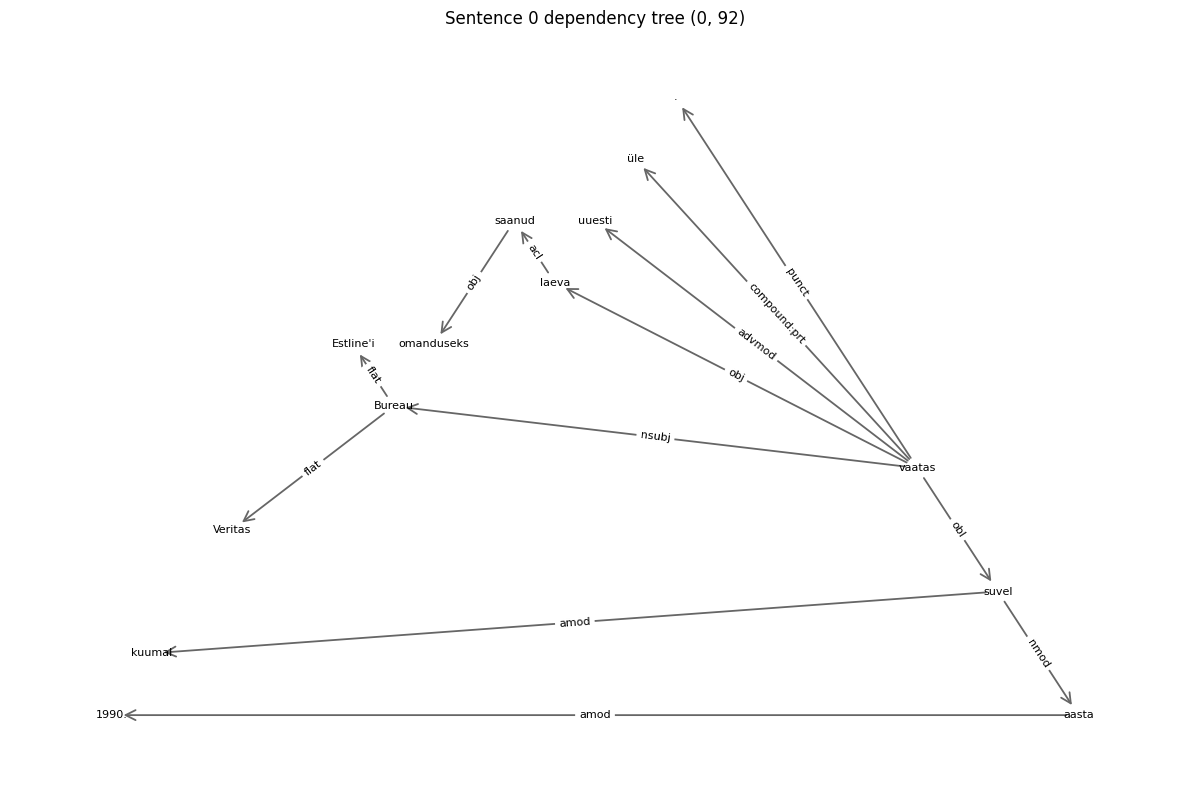

In [104]:
SyntaxGraphIndex.visualize(graph_index, layout="planar", node_size=0, show=False)

In [105]:
# Testing DepChildTagger class and its EstNLTK-compatible wrapper on the sample text with the StanzaSyntaxTagger
tagger = DepChildTagger(
    patterns=(pattern,),
)

status = {}
tagger.tag(text_obj, status=status)
print(status.get("errors"))

None


In [106]:
print(text_obj["dep_chains"])

RelationLayer(name='dep_chains', span_names=('text',), attributes=('pattern_name', 'matched_text', 'upostag', 'xpostag', 'feats', 'lemma', 'deprel', 'role', 'is_anchor'), relations=[Relation([NamedSpan(text: 'vaatas')], [{'pattern_name': 'test', 'matched_text': 'vaatas suvel', 'upostag': 'V', 'xpostag': 'V', 'feats': OrderedDict({'s': 's'}), 'lemma': 'vaatama', 'deprel': 'root', 'role': 'v', 'is_anchor': True}, {'pattern_name': 'test', 'matched_text': 'vaatas laeva', 'upostag': 'V', 'xpostag': 'V', 'feats': OrderedDict({'s': 's'}), 'lemma': 'vaatama', 'deprel': 'root', 'role': 'v', 'is_anchor': True}, {'pattern_name': 'test', 'matched_text': 'vaatas aasta', 'upostag': 'V', 'xpostag': 'V', 'feats': OrderedDict({'s': 's'}), 'lemma': 'vaatama', 'deprel': 'root', 'role': 'v', 'is_anchor': True}, {'pattern_name': 'test', 'matched_text': 'vaatas kuumal', 'upostag': 'V', 'xpostag': 'V', 'feats': OrderedDict({'s': 's'}), 'lemma': 'vaatama', 'deprel': 'root', 'role': 'v', 'is_anchor': True}, {'

In [107]:
display(text_obj["dep_chains"])

RelationLayer(name='dep_chains', span_names=('text',), attributes=('pattern_name', 'matched_text', 'upostag', 'xpostag', 'feats', 'lemma', 'deprel', 'role', 'is_anchor'), relations=[Relation([NamedSpan(text: 'vaatas')], [{'pattern_name': 'test', 'matched_text': 'vaatas suvel', 'upostag': 'V', 'xpostag': 'V', 'feats': OrderedDict({'s': 's'}), 'lemma': 'vaatama', 'deprel': 'root', 'role': 'v', 'is_anchor': True}, {'pattern_name': 'test', 'matched_text': 'vaatas laeva', 'upostag': 'V', 'xpostag': 'V', 'feats': OrderedDict({'s': 's'}), 'lemma': 'vaatama', 'deprel': 'root', 'role': 'v', 'is_anchor': True}, {'pattern_name': 'test', 'matched_text': 'vaatas aasta', 'upostag': 'V', 'xpostag': 'V', 'feats': OrderedDict({'s': 's'}), 'lemma': 'vaatama', 'deprel': 'root', 'role': 'v', 'is_anchor': True}, {'pattern_name': 'test', 'matched_text': 'vaatas kuumal', 'upostag': 'V', 'xpostag': 'V', 'feats': OrderedDict({'s': 's'}), 'lemma': 'vaatama', 'deprel': 'root', 'role': 'v', 'is_anchor': True}, {'pattern_name': 'test', 'matched_text': 'vaatas omanduseks', 'upostag': 'V', 'xpostag': 'V', 'feats': OrderedDict({'s': 's'}), 'lemma': 'vaatama', 'deprel': 'root', 'role': 'v', 'is_anchor': True}]), Relation([NamedSpan(text: 'suvel')], [{'pattern_name': 'test', 'matched_text': 'vaatas suvel', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'ad': 'ad'}), 'lemma': 'suvi', 'deprel': 'obl', 'role': 's_1', 'is_anchor': False}]), Relation([NamedSpan(text: 'laeva')], [{'pattern_name': 'test', 'matched_text': 'vaatas laeva', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'p': 'p'}), 'lemma': 'laev', 'deprel': 'obj', 'role': 's_1', 'is_anchor': False}]), Relation([NamedSpan(text: 'aasta')], [{'pattern_name': 'test', 'matched_text': 'vaatas aasta', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'g': 'g'}), 'lemma': 'aasta', 'deprel': 'nmod', 'role': 's_1', 'is_anchor': False}]), Relation([NamedSpan(text: 'kuumal')], [{'pattern_name': 'test', 'matched_text': 'vaatas kuumal', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'ad': 'ad'}), 'lemma': 'kuum', 'deprel': 'amod', 'role': 's_1', 'is_anchor': False}]), Relation([NamedSpan(text: 'omanduseks')], [{'pattern_name': 'test', 'matched_text': 'vaatas omanduseks', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'tr': 'tr'}), 'lemma': 'omandus', 'deprel': 'obj', 'role': 's_1', 'is_anchor': False}, {'pattern_name': 'test', 'matched_text': 'saanud omanduseks', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'tr': 'tr'}), 'lemma': 'omandus', 'deprel': 'obj', 'role': 's_1', 'is_anchor': False}]), Relation([NamedSpan(text: 'saanud')], [{'pattern_name': 'test', 'matched_text': 'saanud omanduseks', 'upostag': 'V', 'xpostag': 'V', 'feats': OrderedDict({'nud': 'nud'}), 'lemma': 'saama', 'deprel': 'acl', 'role': 'v', 'is_anchor': True}])])

In [108]:
text_obj["dep_chains"].display()

1990. aasta text(3) kuumal text(4) suvel text(1) vaatas text(0) Bureau Veritas Estline'i omanduseks text(5) saanud text(6) laeva text(2) uuesti üle.

### Testing on sample sentence (2)


In [13]:
sample_text = "1990. aasta kuumal suvel vaatas Bureau Veritas Estline'i omanduseks saanud laeva uuesti üle."
text_obj = estnltk.Text(sample_text)
text_obj.tag_layer("morph_extended")
stanza_syntax_tagger.tag(text_obj)

display(text_obj.stanza_syntax)

sentence_layer = text_obj.sentences
stanza_syntax_layer = text_obj.stanza_syntax

# Check the DepChainTaggerOrchestrator implementation with the sample text
pattern = PathPattern(
    name="test",
    node_steps=(
        NodeConstraint(  # vaatas
            role="v",
            attribute_conditions={"upostag": ValueCondition(ConditionMode.EXACT, "V")},
        ),
        NodeConstraint(  # suvel
            role="s_1",
            attribute_conditions={"upostag": ValueCondition(ConditionMode.EXACT, "S")},
        ),
        NodeConstraint(  # aasta
            role="s_2",
            attribute_conditions={"upostag": ValueCondition(ConditionMode.EXACT, "S")},
        ),
        NodeConstraint(  # 1990.
            role="o",
            attribute_conditions={"upostag": ValueCondition(ConditionMode.EXACT, "O")},
        ),
    ),
    edge_steps=(
        EdgeConstraint(
            direction=DirectionMode.DOWN,
            # attribute_conditions={
            #     "deprel": ValueCondition(ConditionMode.EXACT, "nmod")
            # },
            min_hops=1,
            max_hops=1,
        ),
        EdgeConstraint(
            direction=DirectionMode.DOWN,
            attribute_conditions=None,
            min_hops=1,
            max_hops=1,
        ),
        EdgeConstraint(
            direction=DirectionMode.DOWN,
            attribute_conditions=None,
            min_hops=1,
            max_hops=1,
        ),
    ),
    emit_roles=("v", "s_1", "s_2", "o"),
)

orchestrator = DepTaggerOrchestrator(
    patterns=(pattern,),
    global_dedup_mode="none",
    max_total_matches=1000000,
)

for i, sentence in enumerate(sentence_layer):
    sentence_span = (sentence.start, sentence.end)
    print(f"Sentence span: {sentence_span}, text: '{sentence.text}'")
    stanza_syntax_layer_sentence = sentence.stanza_syntax
    # Build syntax graph index from stanza_syntax layer
    graph_index = SyntaxGraphIndex(
        stanza_syntax_layer=stanza_syntax_layer_sentence,
        sentence_id=i,
        sentence_span=sentence_span,
    )

    # Run matcher
    matcher = orchestrator._get_matcher()
    matches = matcher.match_sentence(
        graph_index=graph_index,
        sentence_index=i,
        sentence_span=sentence_span,
    )

    print(f"Found {len(matches)} matches in sentence {i}.")
    for match in matches:
        print(match.describe())
        # for role, node in match.role_to_node.items():
        #     print(role, node.start, node.end, node.text, node.lemma, node.id)
    print("-" * 50)

Layer(name='stanza_syntax', attributes=('id', 'lemma', 'upostag', 'xpostag', 'feats', 'head', 'deprel', 'deps', 'misc', 'parent_span', 'children'), spans=SL[Span('1990.', [{'id': 1, 'lemma': '1990.', 'upostag': 'O', 'xpostag': 'O', 'feats': OrderedDict({'?': '?'}), 'head': 2, 'deprel': 'amod', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('aasta', [{'id': 2, 'lemma': 'aasta', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'g': 'g'}), 'head': 4, 'deprel': 'nmod', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': <class 'tuple'>}]),
Span('kuumal', [{'id': 3, 'lemma': 'kuum', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'ad': 'ad'}), 'head': 4, 'deprel': 'amod', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('suvel', [{'id': 4, 'lemma': 'suvi', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'ad': 'ad'}), 'head': 5, 'deprel': 'obl', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': <class 'tuple'>}]),
Span('vaatas', [{'id': 5, 'lemma': 'vaatama', 'upostag': 'V', 'xpostag': 'V', 'feats': OrderedDict({'s': 's'}), 'head': 0, 'deprel': 'root', 'deps': '_', 'misc': '_', 'parent_span': None, 'children': <class 'tuple'>}]),
Span('Bureau', [{'id': 6, 'lemma': 'Bureau', 'upostag': 'H', 'xpostag': 'H', 'feats': OrderedDict({'sg': 'sg', 'n': 'n'}), 'head': 5, 'deprel': 'nsubj', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': <class 'tuple'>}]),
Span('Veritas', [{'id': 7, 'lemma': 'Veritas', 'upostag': 'H', 'xpostag': 'H', 'feats': OrderedDict({'sg': 'sg', 'n': 'n'}), 'head': 6, 'deprel': 'flat', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span("Estline'i", [{'id': 8, 'lemma': 'Estline', 'upostag': 'H', 'xpostag': 'H', 'feats': OrderedDict({'sg': 'sg', 'g': 'g'}), 'head': 6, 'deprel': 'flat', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('omanduseks', [{'id': 9, 'lemma': 'omandus', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'tr': 'tr'}), 'head': 10, 'deprel': 'obj', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('saanud', [{'id': 10, 'lemma': 'saama', 'upostag': 'V', 'xpostag': 'V', 'feats': OrderedDict({'nud': 'nud'}), 'head': 11, 'deprel': 'acl', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': <class 'tuple'>}]),
Span('laeva', [{'id': 11, 'lemma': 'laev', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'p': 'p'}), 'head': 5, 'deprel': 'obj', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': <class 'tuple'>}]),
Span('uuesti', [{'id': 12, 'lemma': 'uuesti', 'upostag': 'D', 'xpostag': 'D', 'feats': OrderedDict(), 'head': 5, 'deprel': 'advmod', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('üle', [{'id': 13, 'lemma': 'üle', 'upostag': 'D', 'xpostag': 'D', 'feats': OrderedDict(), 'head': 5, 'deprel': 'compound:prt', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('.', [{'id': 14, 'lemma': '.', 'upostag': 'Z', 'xpostag': 'Z', 'feats': OrderedDict(), 'head': 5, 'deprel': 'punct', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}])])

Sentence span: (0, 92), text: '['1990.', 'aasta', 'kuumal', 'suvel', 'vaatas', 'Bureau', 'Veritas', "Estline'i", 'omanduseks', 'saanud', 'laeva', 'uuesti', 'üle', '.']'
Found 1 matches in sentence 0.
Pattern name: test
Sentence index: 0
Sentence span: (0, 92)
Matched roles:
  Role: o, Token ID: 1, Node properties: {start: 0, end: 5, upostag: O, xpostag: O, lemma: 1990., feats: OrderedDict({'?': '?'})}
  Role: s_1, Token ID: 4, Node properties: {start: 19, end: 24, upostag: S, xpostag: S, lemma: suvi, feats: OrderedDict({'sg': 'sg', 'ad': 'ad'})}
  Role: s_2, Token ID: 2, Node properties: {start: 6, end: 11, upostag: S, xpostag: S, lemma: aasta, feats: OrderedDict({'sg': 'sg', 'g': 'g'})}
  Role: v, Token ID: 5, Node properties: {start: 25, end: 31, upostag: V, xpostag: V, lemma: vaatama, feats: OrderedDict({'s': 's'})}
Traversed edges:
  From role: v to role: s_1, Edge context: {direction: down, deprel: obl, hops: 1, crosses_sentence: False}
  From role: s_1 to role: s_2, Edge context:

In [14]:
# Testing DepChildTagger class and its EstNLTK-compatible wrapper on the sample text with the StanzaSyntaxTagger
tagger = DepChildTagger(
    patterns=(pattern,),
)

status = {}
tagger.tag(text_obj, status=status)
print(status.get("errors"))

None


In [15]:
print(text_obj["dep_chains"])

RelationLayer(name='dep_chains', span_names=('text',), attributes=('pattern_name', 'matched_text', 'upostag', 'xpostag', 'feats', 'lemma', 'deprel', 'role', 'is_anchor'), relations=[Relation([NamedSpan(text: 'vaatas')], [{'pattern_name': 'test', 'matched_text': 'vaatas suvel aasta 1990.', 'upostag': 'V', 'xpostag': 'V', 'feats': OrderedDict({'s': 's'}), 'lemma': 'vaatama', 'deprel': 'root', 'role': 'v', 'is_anchor': True}]), Relation([NamedSpan(text: 'suvel')], [{'pattern_name': 'test', 'matched_text': 'vaatas suvel aasta 1990.', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'ad': 'ad'}), 'lemma': 'suvi', 'deprel': 'obl', 'role': 's_1', 'is_anchor': False}]), Relation([NamedSpan(text: 'aasta')], [{'pattern_name': 'test', 'matched_text': 'vaatas suvel aasta 1990.', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'g': 'g'}), 'lemma': 'aasta', 'deprel': 'nmod', 'role': 's_2', 'is_anchor': False}]), Relation([NamedSpan(text: '1990.')], [{'pattern_name'

In [16]:
display(text_obj["dep_chains"])

RelationLayer(name='dep_chains', span_names=('text',), attributes=('pattern_name', 'matched_text', 'upostag', 'xpostag', 'feats', 'lemma', 'deprel', 'role', 'is_anchor'), relations=[Relation([NamedSpan(text: 'vaatas')], [{'pattern_name': 'test', 'matched_text': 'vaatas suvel aasta 1990.', 'upostag': 'V', 'xpostag': 'V', 'feats': OrderedDict({'s': 's'}), 'lemma': 'vaatama', 'deprel': 'root', 'role': 'v', 'is_anchor': True}]), Relation([NamedSpan(text: 'suvel')], [{'pattern_name': 'test', 'matched_text': 'vaatas suvel aasta 1990.', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'ad': 'ad'}), 'lemma': 'suvi', 'deprel': 'obl', 'role': 's_1', 'is_anchor': False}]), Relation([NamedSpan(text: 'aasta')], [{'pattern_name': 'test', 'matched_text': 'vaatas suvel aasta 1990.', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'g': 'g'}), 'lemma': 'aasta', 'deprel': 'nmod', 'role': 's_2', 'is_anchor': False}]), Relation([NamedSpan(text: '1990.')], [{'pattern_name': 'test', 'matched_text': 'vaatas suvel aasta 1990.', 'upostag': 'O', 'xpostag': 'O', 'feats': OrderedDict({'?': '?'}), 'lemma': '1990.', 'deprel': 'amod', 'role': 'o', 'is_anchor': False}])])

In [17]:
text_obj["dep_chains"].display()

1990. text(3) aasta text(2) kuumal suvel text(1) vaatas text(0) Bureau Veritas Estline'i omanduseks saanud laeva uuesti üle.

### Testing on sample sentence (3)


In [18]:
sample_text = "1990. aasta kuumal suvel vaatas Bureau Veritas Estline'i omanduseks saanud laeva uuesti üle."
text_obj = estnltk.Text(sample_text)
text_obj.tag_layer("morph_extended")
stanza_syntax_tagger.tag(text_obj)

display(text_obj.stanza_syntax)

sentence_layer = text_obj.sentences
stanza_syntax_layer = text_obj.stanza_syntax

# Check the DepChainTaggerOrchestrator implementation with the sample text
pattern = PathPattern(
    name="test",
    node_steps=(
        NodeConstraint(  # vaatas
            role="o",
            attribute_conditions={"upostag": ValueCondition(ConditionMode.EXACT, "O")},
        ),
        NodeConstraint(  # suvel
            role="s_1",
            attribute_conditions={"upostag": ValueCondition(ConditionMode.EXACT, "S")},
        ),
        NodeConstraint(  # aasta
            role="s_2",
            attribute_conditions={"upostag": ValueCondition(ConditionMode.EXACT, "S")},
        ),
        NodeConstraint(  # 1990.
            role="v",
            attribute_conditions={"upostag": ValueCondition(ConditionMode.EXACT, "V")},
        ),
    ),
    edge_steps=(
        EdgeConstraint(
            direction=DirectionMode.UP,
            # attribute_conditions={
            #     "deprel": ValueCondition(ConditionMode.EXACT, "nmod")
            # },
            min_hops=1,
            max_hops=1,
        ),
        EdgeConstraint(
            direction=DirectionMode.UP,
            attribute_conditions=None,
            min_hops=1,
            max_hops=1,
        ),
        EdgeConstraint(
            direction=DirectionMode.UP,
            attribute_conditions=None,
            min_hops=1,
            max_hops=1,
        ),
    ),
    emit_roles=("o", "s_1", "s_2", "v"),
)

orchestrator = DepTaggerOrchestrator(
    patterns=(pattern,),
    global_dedup_mode="none",
    max_total_matches=1000000,
)

for i, sentence in enumerate(sentence_layer):
    sentence_span = (sentence.start, sentence.end)
    print(f"Sentence span: {sentence_span}, text: '{sentence.text}'")
    stanza_syntax_layer_sentence = sentence.stanza_syntax
    # Build syntax graph index from stanza_syntax layer
    graph_index = SyntaxGraphIndex(
        stanza_syntax_layer=stanza_syntax_layer_sentence,
        sentence_id=i,
        sentence_span=sentence_span,
    )

    # Run matcher
    matcher = orchestrator._get_matcher()
    matches = matcher.match_sentence(
        graph_index=graph_index,
        sentence_index=i,
        sentence_span=sentence_span,
    )

    print(f"Found {len(matches)} matches in sentence {i}.")
    for match in matches:
        print(match.describe())
        # for role, node in match.role_to_node.items():
        #     print(role, node.start, node.end, node.text, node.lemma, node.id)
    print("-" * 50)

Layer(name='stanza_syntax', attributes=('id', 'lemma', 'upostag', 'xpostag', 'feats', 'head', 'deprel', 'deps', 'misc', 'parent_span', 'children'), spans=SL[Span('1990.', [{'id': 1, 'lemma': '1990.', 'upostag': 'O', 'xpostag': 'O', 'feats': OrderedDict({'?': '?'}), 'head': 2, 'deprel': 'amod', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('aasta', [{'id': 2, 'lemma': 'aasta', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'g': 'g'}), 'head': 4, 'deprel': 'nmod', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': <class 'tuple'>}]),
Span('kuumal', [{'id': 3, 'lemma': 'kuum', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'ad': 'ad'}), 'head': 4, 'deprel': 'amod', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('suvel', [{'id': 4, 'lemma': 'suvi', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'ad': 'ad'}), 'head': 5, 'deprel': 'obl', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': <class 'tuple'>}]),
Span('vaatas', [{'id': 5, 'lemma': 'vaatama', 'upostag': 'V', 'xpostag': 'V', 'feats': OrderedDict({'s': 's'}), 'head': 0, 'deprel': 'root', 'deps': '_', 'misc': '_', 'parent_span': None, 'children': <class 'tuple'>}]),
Span('Bureau', [{'id': 6, 'lemma': 'Bureau', 'upostag': 'H', 'xpostag': 'H', 'feats': OrderedDict({'sg': 'sg', 'n': 'n'}), 'head': 5, 'deprel': 'nsubj', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': <class 'tuple'>}]),
Span('Veritas', [{'id': 7, 'lemma': 'Veritas', 'upostag': 'H', 'xpostag': 'H', 'feats': OrderedDict({'sg': 'sg', 'n': 'n'}), 'head': 6, 'deprel': 'flat', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span("Estline'i", [{'id': 8, 'lemma': 'Estline', 'upostag': 'H', 'xpostag': 'H', 'feats': OrderedDict({'sg': 'sg', 'g': 'g'}), 'head': 6, 'deprel': 'flat', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('omanduseks', [{'id': 9, 'lemma': 'omandus', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'tr': 'tr'}), 'head': 10, 'deprel': 'obj', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('saanud', [{'id': 10, 'lemma': 'saanud', 'upostag': 'A', 'xpostag': 'A', 'feats': OrderedDict({'pl': 'pl', 'n': 'n'}), 'head': 11, 'deprel': 'acl', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': <class 'tuple'>}]),
Span('laeva', [{'id': 11, 'lemma': 'laev', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'sg': 'sg', 'p': 'p'}), 'head': 5, 'deprel': 'obj', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': <class 'tuple'>}]),
Span('uuesti', [{'id': 12, 'lemma': 'uuesti', 'upostag': 'D', 'xpostag': 'D', 'feats': OrderedDict(), 'head': 5, 'deprel': 'advmod', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('üle', [{'id': 13, 'lemma': 'üle', 'upostag': 'D', 'xpostag': 'D', 'feats': OrderedDict(), 'head': 5, 'deprel': 'compound:prt', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('.', [{'id': 14, 'lemma': '.', 'upostag': 'Z', 'xpostag': 'Z', 'feats': OrderedDict(), 'head': 5, 'deprel': 'punct', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}])])

Sentence span: (0, 92), text: '['1990.', 'aasta', 'kuumal', 'suvel', 'vaatas', 'Bureau', 'Veritas', "Estline'i", 'omanduseks', 'saanud', 'laeva', 'uuesti', 'üle', '.']'
Found 1 matches in sentence 0.
Pattern name: test
Sentence index: 0
Sentence span: (0, 92)
Matched roles:
  Role: o, Token ID: 1, Node properties: {start: 0, end: 5, upostag: O, xpostag: O, lemma: 1990., feats: OrderedDict({'?': '?'})}
  Role: s_1, Token ID: 2, Node properties: {start: 6, end: 11, upostag: S, xpostag: S, lemma: aasta, feats: OrderedDict({'sg': 'sg', 'g': 'g'})}
  Role: s_2, Token ID: 4, Node properties: {start: 19, end: 24, upostag: S, xpostag: S, lemma: suvi, feats: OrderedDict({'sg': 'sg', 'ad': 'ad'})}
  Role: v, Token ID: 5, Node properties: {start: 25, end: 31, upostag: V, xpostag: V, lemma: vaatama, feats: OrderedDict({'s': 's'})}
Traversed edges:
  From role: o to role: s_1, Edge context: {direction: up, deprel: amod, hops: 1, crosses_sentence: False}
  From role: s_1 to role: s_2, Edge context: 

In [19]:
# Testing DepChildTagger class and its EstNLTK-compatible wrapper on the sample text with the StanzaSyntaxTagger
tagger = DepChildTagger(
    patterns=(pattern,),
)

status = {}
tagger.tag(text_obj, status=status)
print(status.get("errors"))

ValueError: DepChildTagger only supports DOWN edge constraints; pattern 'test' has edge with direction <DirectionMode.UP: 'up'>.

In [ ]:
print(text_obj["dep_chains"])

RelationLayer(name='dep_chains', span_names=('text',), attributes=('pattern_name', 'matched_text', 'upostag', 'xpostag', 'feats', 'lemma', 'deprel', 'role', 'is_anchor'), relations=[])


In [ ]:
display(text_obj["dep_chains"])

RelationLayer(name='dep_chains', span_names=('text',), attributes=('pattern_name', 'matched_text', 'upostag', 'xpostag', 'feats', 'lemma', 'deprel', 'role', 'is_anchor'), relations=[])

In [ ]:
text_obj["dep_chains"].display()

1990. aasta kuumal suvel vaatas Bureau Veritas Estline'i omanduseks saanud laeva uuesti üle.